In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Reshape 28x28 images into 784 features
x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
def create_model(lr):
    m = Sequential([
        Dense(128, activation='relu', input_shape=(784,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    m.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return m

In [4]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]
results = []

for lr in learning_rates:
    model = create_model(lr)

    model.fit(
        x_train,
        y_train,
        epochs=5,
        batch_size=128,
        verbose=0
    )

    loss, acc = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    results.append([lr, acc])

df = pd.DataFrame(
    results,
    columns=['Learning Rate', 'Accuracy']
)

print(df)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Learning Rate  Accuracy
0         0.1000    0.7541
1         0.0100    0.9726
2         0.0010    0.9721
3         0.0001    0.9448


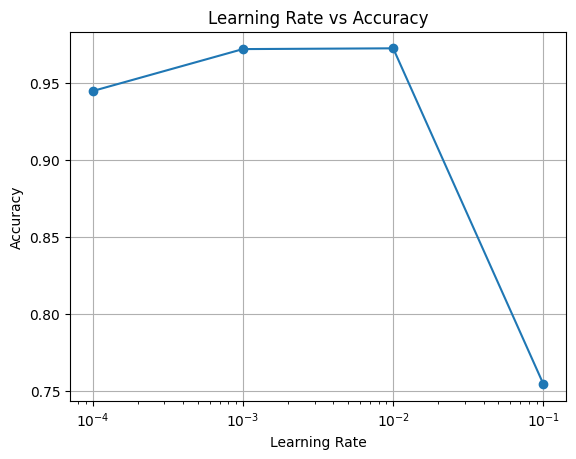

In [5]:
plt.plot(
    df['Learning Rate'],
    df['Accuracy'],
    marker='o'
)

plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.title('Learning Rate vs Accuracy')
plt.grid()
plt.show()

In [6]:
epochs_list = [5, 10, 20]
res = []

for ep in epochs_list:
    model = create_model(0.001)

    h = model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=ep,
        batch_size=128,
        verbose=0
    )

    loss, acc = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    res.append([ep, acc])

edf = pd.DataFrame(
    res,
    columns=['Epochs', 'Accuracy']
)

print(edf)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Epochs  Accuracy
0       5    0.9735
1      10    0.9752
2      20    0.9736


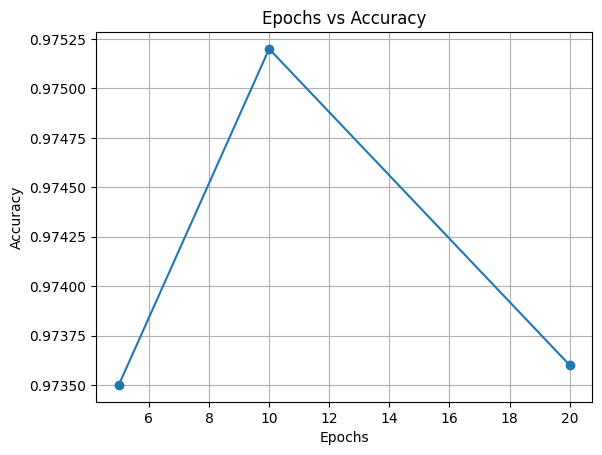

In [7]:
plt.plot(
    edf['Epochs'],
    edf['Accuracy'],
    marker='o'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Epochs vs Accuracy')
plt.grid()
plt.show()

In [8]:
model = create_model(0.001)

history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8931 - loss: 0.3737 - val_accuracy: 0.9498 - val_loss: 0.1816
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9541 - loss: 0.1565 - val_accuracy: 0.9598 - val_loss: 0.1356
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9672 - loss: 0.1109 - val_accuracy: 0.9677 - val_loss: 0.1094
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9763 - loss: 0.0815 - val_accuracy: 0.9672 - val_loss: 0.1037
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9809 - loss: 0.0647 - val_accuracy: 0.9722 - val_loss: 0.0925
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9849 - loss: 0.0507 - val_accuracy: 0.9716 - val_loss: 0.0906
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9870 - loss: 0.0421 - val_accuracy: 0.9729 - val_loss: 0.0929
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9894 - loss: 0.0342 - val_accuracy: 0.

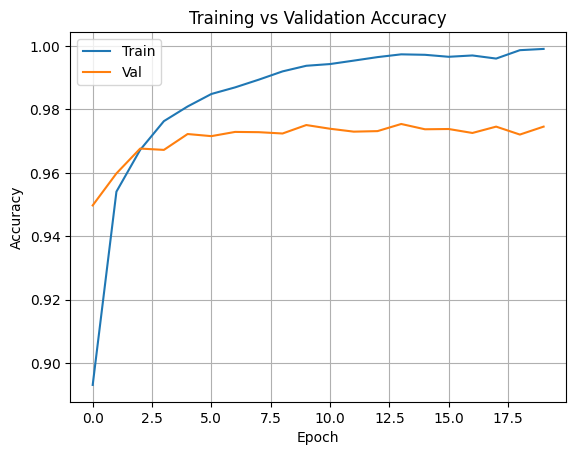

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Train', 'Val'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.grid()
plt.show()

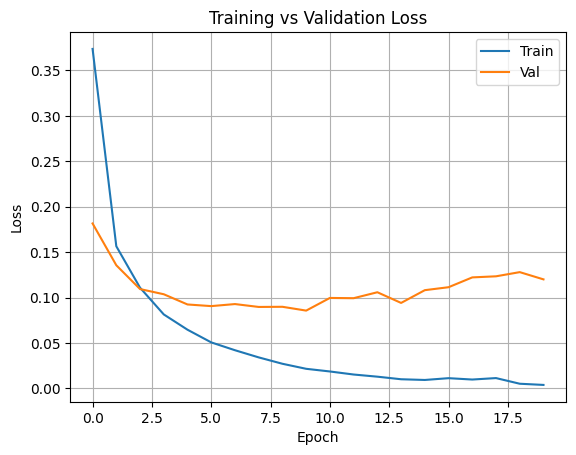

In [10]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(['Train', 'Val'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.grid()
plt.show()

In [11]:
loss, accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Final Test Loss:", loss)
print("Final Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9766 - loss: 0.1140
Final Test Loss: 0.11402788013219833
Final Test Accuracy: 0.9765999913215637


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


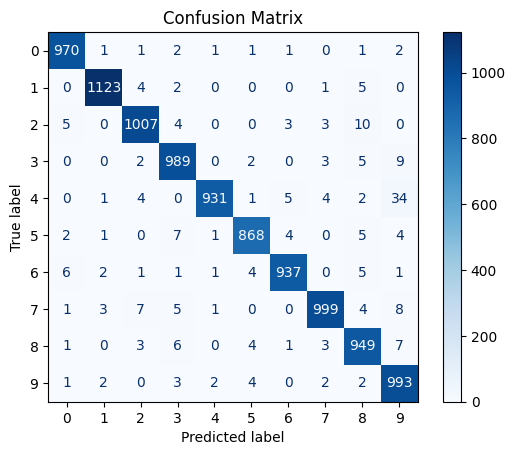

In [12]:
pred = np.argmax(
    model.predict(x_test),
    axis=1
)

cm = confusion_matrix(
    y_test,
    pred
)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()